# Домашнее задание 2. Микросервисная архитектура
Дементьев Михаил 26 апреля


Это задание выполняется в рамках модуля 2 «Микросервисная архитектура». Вы закрепите навыки разделения монолита на микросервисы.

> Чтобы получить максимальный балл, убедитесь, что ваш ноутбук запускается с нуля, структура понятна, а в выводах вы объясняете свои решения.  

## Подготовка окружения

In [3]:
%%capture
!sudo apt install graphviz
!pip install docker-compose-diagram
!pip install fastapi uvicorn[standard] -qq
!pip install --upgrade sqlalchemy
!pip install diagrams

### Задание 1. Сравнить монолитную и микросервисную архитектуру: преимущества и недостатки



*Ожидаемый артефакт: текст в [ячейке](#scrollTo=H75wvgdMk3AV)*

* В каком случае вы не будете разбивать монолит на микросервисы и почему?


* В каком случае монолит обязательно разбивать на микросервисы и почему?

Монолит предпочтителен для высоконагруженных систем с требованием к сверхнизкой задержке, где каждый микросекунда на счету, так как любые межсервисные вызовы через L7 (HTTP/gRPC) или L4 (TCP) добавляют неизбежный сетевой оверхед, сериализацию и буферизацию, которые в монолите заменяются простым вызовом функции в адресном пространстве. Если приложение уже достигает тысяч RPS на одном узле и критична детерминированная задержка без джиттера, то разбиение на микросервисы только ухудшит ситуацию из‑за дополнительных RTT, локов и потерь пакетов. Поэтому я оставляю монолит, когда нагрузка очень высока, а транзакционная логика требует плотного взаимодействия компонентов, не терпящего даже малых задержек сети. В таких случаях экономия на распределённых вызовах перевешивает все преимущества микросервисов.

### Задание 2. Разбить монолит на микросервисы

Есть монолитное веб-приложение. Четыре отдела генерируют нагрузку по 100 RPS каждый (суммарно ≈400 RPS), а текущая пропускная способность веб-сервера — ≈200 RPS; начинает ощущаться деградация. Для упрощения считаем, что сеть не узкое место, ресурсов RAM/CPU/HDD достаточно, техдолг низкий, финансовых ограничений нет.

Задача. Опишите в 5–8 предложениях ваш подход к декомпозиции монолита:
- Как вы диагностируете связность и выбираете границы сервисов (по доменам, бизнес-процессам или данным, допустим комбинированный вариант).
- Какие части вы вынесете первыми, чтобы снять узкое место по RPS, и почему.
- Как будете обеспечивать временную совместную работу старого и нового (этапный переход, strangler pattern).
- Кто владеет данными после разделения и как вы минимизируете риски согласованности.
- Нужен ли API-Gateway на входе и какие задачи он возьмет (маршрутизация, аутентификация, агрегация).

*Ожидаемый артефакт: исправленная диаграмма в [ячейке](#scrollTo=7CLn9-ElzGph). Если не получается создать программно, то можно создать диаграмму с помощью [сервиса](https://app.diagrams.net/)*



Для декомпозиции сначала анализирую связность по бизнес-процессам и данным, выделяя слабо связанные домены. Первыми выношу компоненты, создающие наибольшую нагрузку, чтобы снять узкое место. Для плавного перехода применяю паттерн Strangler с маршрутизацией трафика между старым и новым. Каждый сервис получает собственную базу данных, согласованность поддерживаю через асинхронные события. API Gateway на входе обязателен для маршрутизации, централизованной аутентификации и агрегации данных.

In [4]:
from diagrams import Cluster, Diagram
from diagrams.onprem.compute import Server
from diagrams.aws.database import RDS
from diagrams.onprem.client import Users
from diagrams.onprem.network import Nginx
from diagrams import Diagram, Cluster
from diagrams.programming.language import Python
from diagrams.onprem.database import PostgreSQL
from diagrams.onprem.workflow import Airflow
from diagrams.programming.flowchart import Action
from diagrams.onprem.inmemory import Redis

In [5]:
%%writefile /content/diagram.py

with Diagram("microservices", show=False, direction="LR"):
    with Cluster("Отделы"):
        depts = [Users("логистика"), Users("закупки"), Users("контроль качества"), Users("бухгалтерия")]

    gateway = Nginx("API Gateway")

    with Cluster("Микросервисы"):
        logistics = Server("Сервис логистики\n(100 RPS)")
        monolith_remain = Server("Остатки монолита\n(300 RPS)")
        db_log = RDS("БД логистики")
        db_mono = RDS("БД монолита")

    depts[0] >> gateway >> logistics >> db_log
    for i in range(1,4):
        depts[i] >> gateway >> monolith_remain >> db_mono

Overwriting /content/diagram.py


Traceback (most recent call last):
  File "/content/diagram.py", line 2, in <module>
    with Diagram("microservices", show=False, direction="LR"):
         ^^^^^^^
NameError: name 'Diagram' is not defined


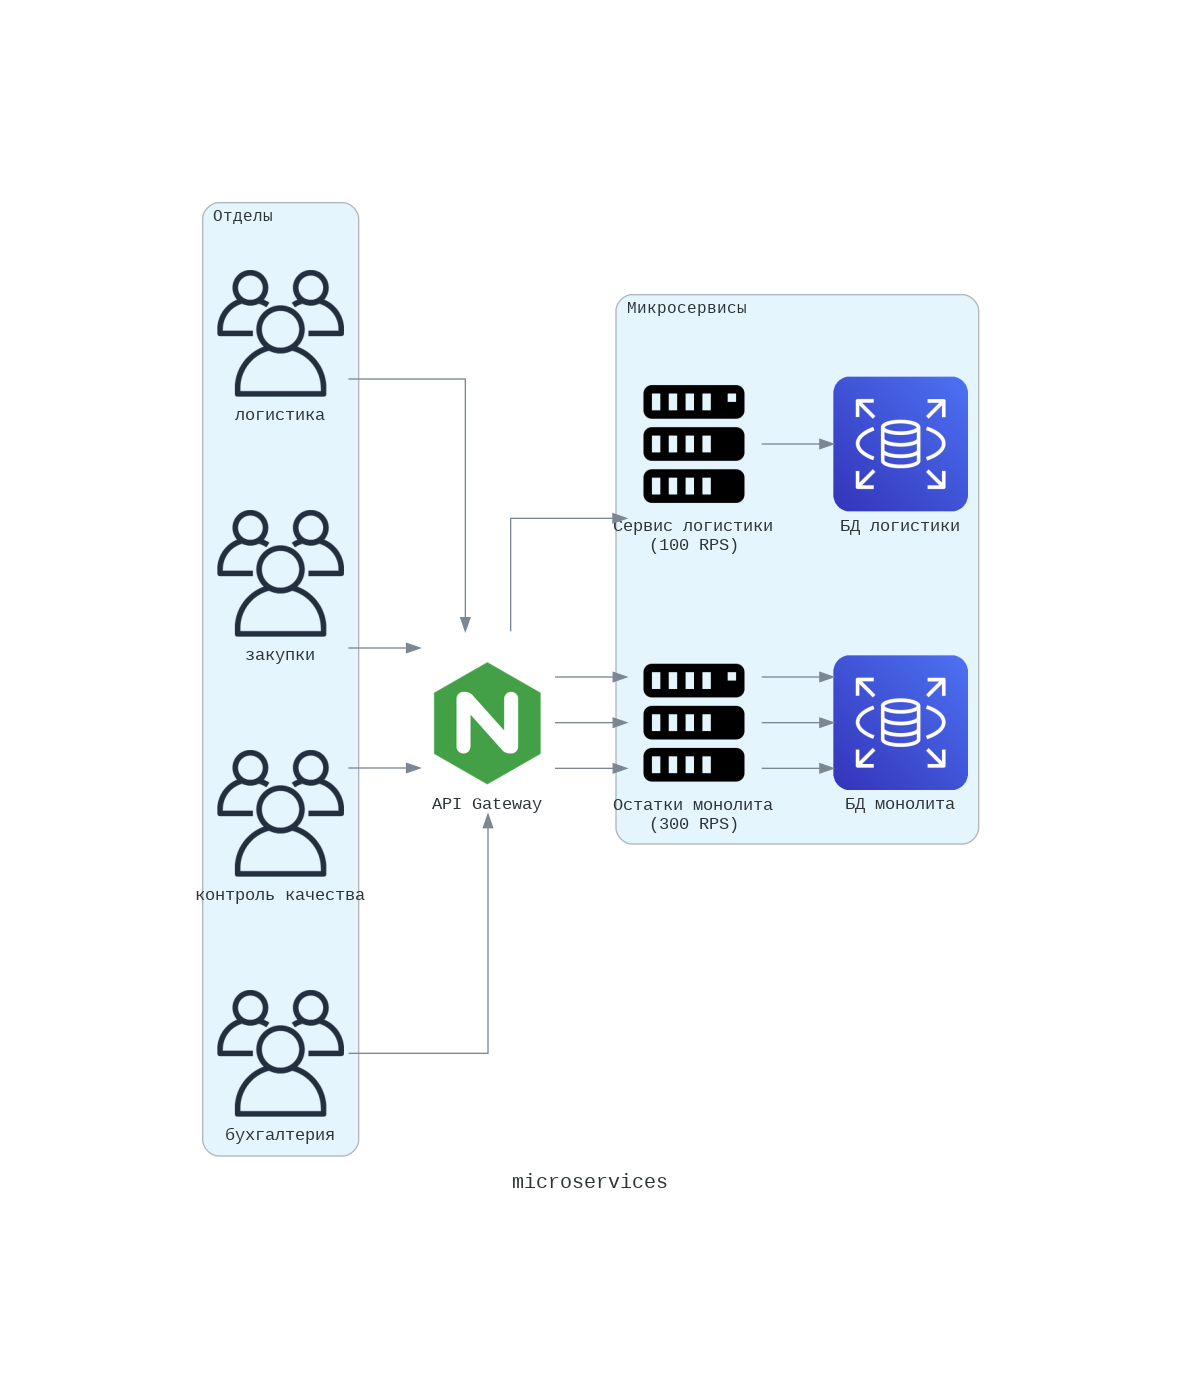

In [6]:
from IPython.display import Image, display
!python diagram.py
image_path = '/content/microservices.png'
display(Image(filename=image_path))

### Задание 3. Составить документацию взаимодействия сервисов, используя библиотеку docker-compose-diagram

Изучите нотацию библиотеки [Diagrams](https://diagrams.mingrammer.com/docs/nodes/onprem) для указания изображений узлов.

Изучите библиотеку [docker-compose-diagram](https://github.com/skonik/docker-compose-diagram) для документирования докер-компоуз-файлов с помощью лейблов.

Создайте диаграмму простого взаимодействия сервисов (веб-сервер и база данных) добавляя лейблы, чтобы получилось примерно как изображено на рисунке.

*Ожидаемый артефакт: диаграмма в [ячейке](#scrollTo=Y_lwPFFH2TIM). Если не получается создать программно, то можно создать диаграмму с помощью [сервиса](https://app.diagrams.net/)*

%%html

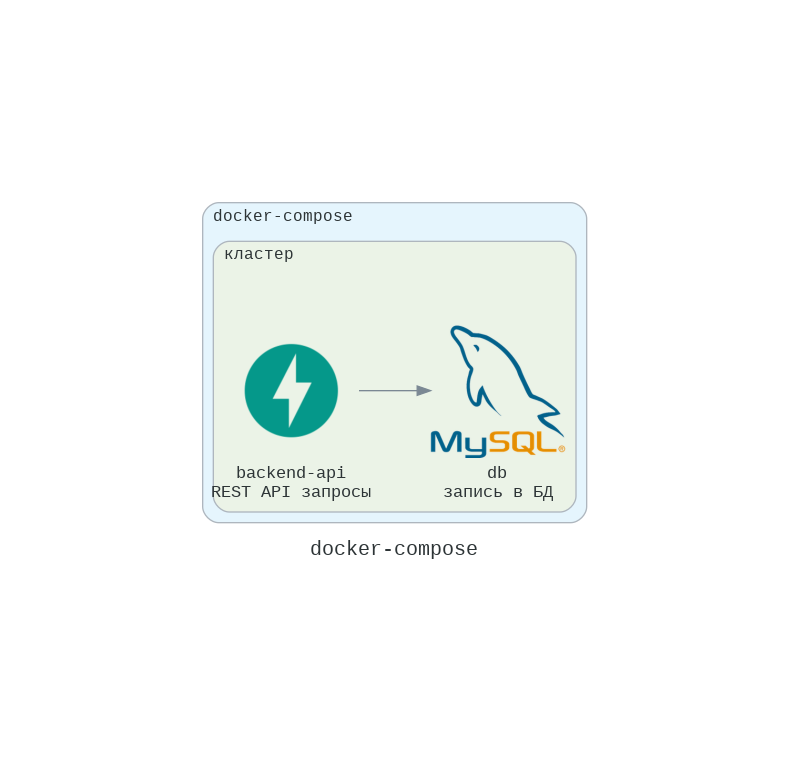

In [7]:
%%writefile docker-compose.yml
services:
  backend-api:
    image: dev_backend
    ports:
      - "8000:8000"
    labels:
      "docker_compose_diagram.icon": "diagrams.programming.framework.FastAPI"
      "docker_compose_diagram.cluster": "Сервисы"
      "docker_compose_diagram.description": "API"

  db:
    image: mysql/mysql-server:8
    ports:
      - "3306:3306"
    labels:
      "docker_compose_diagram.icon": "diagrams.onprem.database.MySQL"
      "docker_compose_diagram.cluster": "Сервисы"
      "docker_compose_diagram.description": "БД"

Overwriting docker-compose.yml


In [8]:
!compose-diagram --file docker-compose.yml --direction=LR --nodesep=1.5 --nodesep=1.2

File docker-compose.yml has been found. Reading! 📗 
Service: backend-api
   Service: {'docker_compose_diagram.icon': 
'diagrams.programming.framework.FastAPI', 'docker_compose_diagram.cluster': 
'Сервисы', 'docker_compose_diagram.description': 'API'}
Service: db
   Service: {'docker_compose_diagram.icon': 'diagrams.onprem.database.MySQL', 
'docker_compose_diagram.cluster': 'Сервисы', 
'docker_compose_diagram.description': 'БД'}
Your diagram has been saved in docker-compose.png 🖼️
⠹ Working..


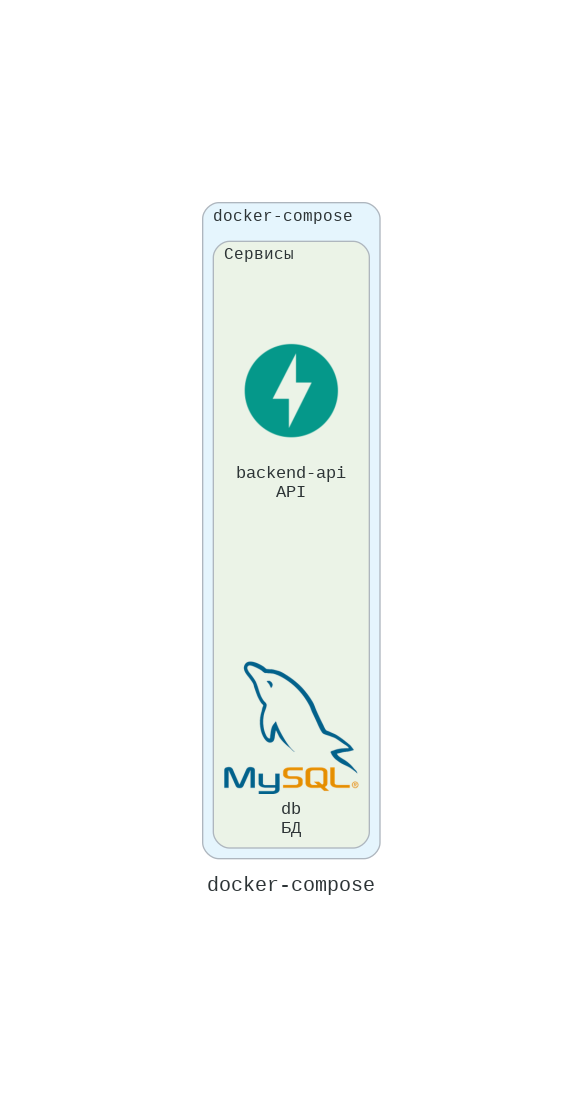

In [9]:
display(Image(filename='docker-compose.png'))

### Задание 4. Выбрать подходящие паттерны интеграции сервисов (REST/gRPC/брокеры)

Есть монолитное веб-приложение с пропускной способностью ≈200 RPS, при росте нагрузки до ≈400 RPS начинает ощущаться деградация.

Предложите 3 гипотезы, основываясь на [HDD-подходе](https://colab.research.google.com/drive/1vzl2jhLMJuLN-ZcYiPiIeJ7ribHMGDwt?usp=sharing) и исходя из вводных данных:

## REST (будет выдавать 1000 RPS)
* DevCost = 120000 — зарплата разработчиков.
* InfraCost =  50000 — стоимость инфраструктуры.
* featureEstimate = 85 — оценка фичи в стори-поинтах.
* ReworkRate =  0.2; процент доработок/исправлений — от 0.0 до 1.0.

## gRPC (будет выдавать 10000 RPS)

* DevCost = 1000000 — зарплата разработчиков.
* InfraCost =  500000 — стоимость инфраструктуры.
* featureEstimate = 850 — оценка фичи в стори-поинтах.
* ReworkRate =  0.4; процент доработок/исправлений — от 0.0 до 1.0.

## брокеры (будет выдавать 1000000 RPS)

* DevCost = 1200000 — зарплата разработчиков.
* InfraCost =  1500000 — стоимость инфраструктуры.
* featureEstimate = 8500 — оценка фичи в стори-поинтах.
* ReworkRate =  0.6; процент доработок/исправлений — от 0.0 до 1.0.

*Ожидаемый артефакт: текст в [ячейке](#scrollTo=6d6BctG4l6A8)*

Ваше решение здесь

### Задание 5. Разработать схему ML-системы для обработки табличных данных

**Вводные данные от бизнеса: «Как привлечь клиентов на депозит?» и результат прошлой маркетинговой кампании.**

Нужно составить список вопросов, без каких микросервисов невозможно начать разработку ML-системы, выбрать архитектуру и составить схематическое описание ML-системы с помощью библиотеки Diagrams.

**Писать ML-код не нужно.**

*Ожидаемый артефакт: диаграмма в [ячейке](#scrollTo=lQH02crYmlkL). Если не получается создать программно, то можно создать диаграмму с помощью [сервиса](https://app.diagrams.net/)*

Основываясь на HDD подходе, выдвигаю три гипотезы. Первая гипотеза: REST справится с требуемой нагрузкой 400 RPS, так как его паспортная пропускная способность 1000 RPS даёт двукратный запас, а суммарные затраты (DevCost 120000 + InfraCost 50000 = 170000) минимальны, плюс низкий процент доработок 0.2 укладывается в бюджет. Вторая гипотеза: gRPC избыточен для 400 RPS, поскольку 10000 RPS многократно превышают потребность, однако его стоимость (1 500 000) почти в 9 раз выше, а сложность (featureEstimate 850, ReworkRate 0.4) окупится только при реальной потребности в 5000+ RPS или двунаправленной потоковой передаче, чего в условиях нет. Третья гипотеза: брокеры сообщений (1000000 RPS) чрезмерно дороги (InfraCost 1500000, DevCost 1200000, featureEstimate 8500, ReworkRate 0.6) и не нужны для синхронного запрос-ответного взаимодействия, но могут пригодиться, если логика станет асинхронной (например, очереди задач). Итоговый выбор REST как оптимальный по соотношению цена/производительность для 400 RPS.

In [17]:
!pip install diagrams

In [22]:
%%writefile ml_diagram.py
from diagrams import Cluster, Diagram
from diagrams.programming.language import Python
from diagrams.onprem.database import PostgreSQL
from diagrams.onprem.mlops import Mlflow   # <- Исправлено: Mlflow вместо MLflow
from diagrams.onprem.workflow import Airflow
from diagrams.programming.flowchart import Action
from diagrams.onprem.inmemory import Redis

with Diagram("ML_system", show=False, direction="LR", filename="ml_system"):
    source = PostgreSQL("БД клиентов")
    etl = Airflow("ETL")
    features = Redis("Feature Store")
    trainer = Python("Train")
    mlflow = Mlflow("MLflow")
    predictor = Action("Prediction API")
    consumer = Action("Менеджер")

    source >> etl >> features
    features >> trainer
    trainer >> mlflow
    mlflow >> predictor
    predictor >> consumer
    consumer >> etl

Overwriting ml_diagram.py


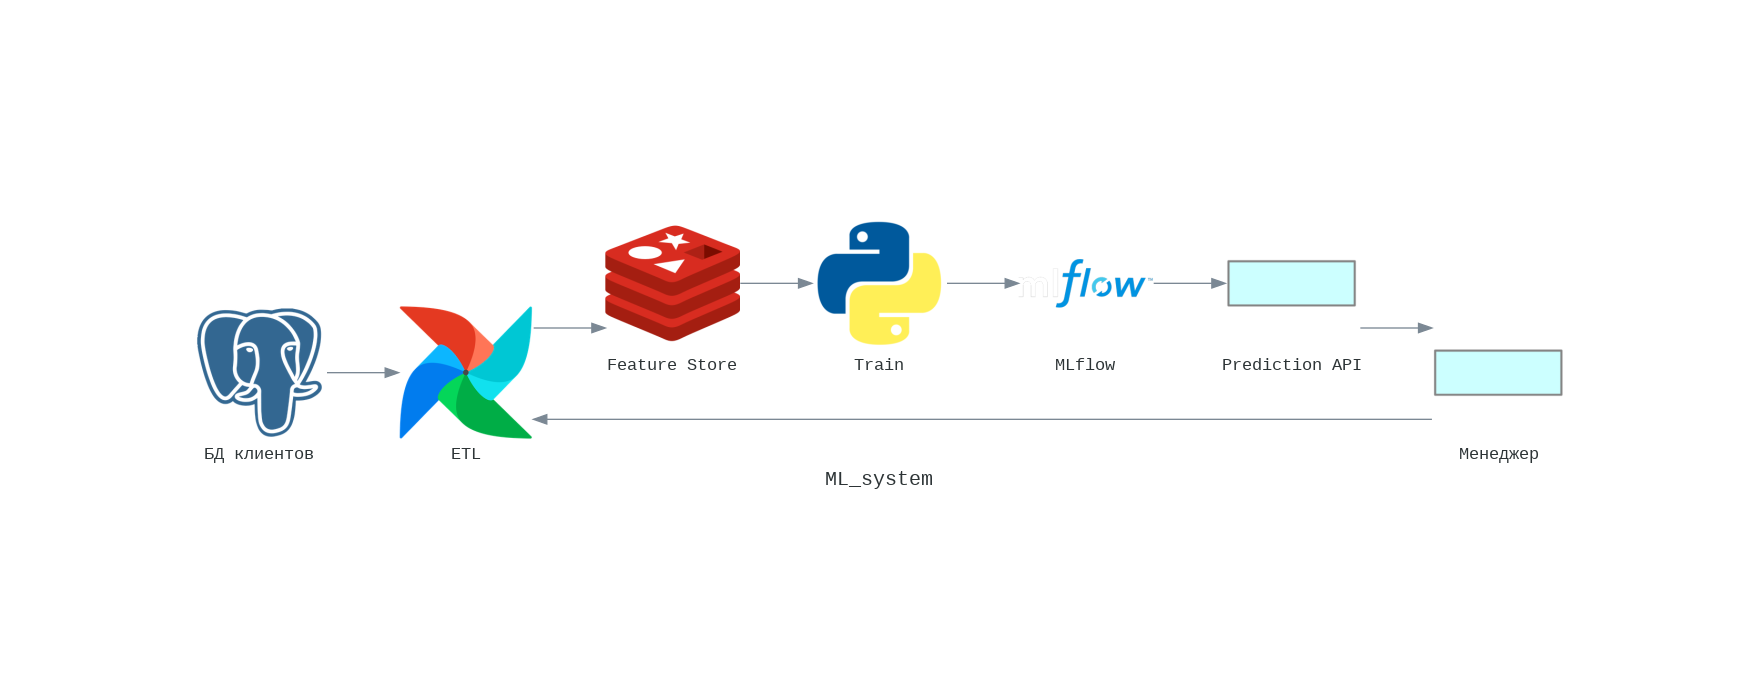

In [23]:
!python ml_diagram.py
from IPython.display import Image, display
display(Image("ml_system.png"))  # имя файла из filename= в Diagram

## Итоговое оформление

1. Сформулируйте ниже 5–8 выводов, когда стоит разбивать монолит на микросервисы.
2. Опишите в 5–8 предложениях ваш подход к декомпозиции монолита.
3. Запустите блокнот, чтобы получить диаграмму простого взаимодействия сервисов (веб-сервер и база данных), используя лейблы.
4. Обоснуйте в 5–8 предложениях выбранный паттерн интеграции сервисов.
5. Без чего немыслимо начинать разработку ML-системы?
6. Проверьте, что ноутбук запускается.  